# Predicting Content Virality on YouTube/TikTok
## Binary Classification: Predicting "Rising" Content Trends (2025)

**Target Variable:** `target = (trend_label == "rising").astype(int)`

---
This project implements a supervised binary classification framework to predict the virality of social media content. By leveraging metadata and performance metrics from YouTube and TikTok, the model aims to distinguish between "rising" content—classified as viral—and non-viral content. The analysis adheres to a rigorous machine learning lifecycle, prioritizing methodological integrity, data quality, and model interpretability.


## 1 Environment Setup

All library imports and environment configurations are consolidated in this section to ensure the notebook's reproducibility and streamline the dependency management process

### 1.1 Imports

In [10]:
# -- Paths --- 
from pathlib import Path

# --- Data manipulation ---
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Statistics test ---
from scipy.stats import chi2_contingency, mannwhitneyu

# --- Scikit-Learn: partitioning e validation ---
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold

# --- Scikit-Learn: preprocessing e pipeline ---
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# --- Scikit-Learn: models ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

# --- Scikit-Learn: metrics ---
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve, classification_report,
)

# --- Explainable AI ---
import shap

### 1.2 Configuration

In [11]:
# --- Replicability ---
RANDOM_STATE = 107

# --- Visualization settings ---
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
np.random.seed(RANDOM_STATE)

print("Setup completed.")
print(f"  pandas : {pd.__version__}")
print(f"  numpy  : {np.__version__}")
print(f"  shap   : {shap.__version__}")

Setup completed.
  pandas : 3.0.3
  numpy  : 2.4.6
  shap   : 0.52.0


## 2. Data ingestion & Partitionig

The partitioning is carried out immediately after loading, prior to any in-depth inspection, imputation, or scaling.The reason is methodological. 

The split is stratified on the target to preserve class proportions. 

One column is removed prior to any other consideration: row_id — a unique identifier. It conveys no generalizable information and, in a tree-based model, only provides opportunities to memorize the Training Set.

### 2.1 Data import

In [12]:
# --- Dataset import ---
dataset_path = Path("Data") / "raw_tiktok_youtube_trends.csv"
datadict_path = Path("Data") / "DATA_DICTIONARY.csv"

df_raw = pd.read_csv(dataset_path, encoding="utf-8-sig")
data_dictionary = pd.read_csv(datadict_path)

print(f"Raw dataset dimensions: {df_raw.shape[0]} righe x {df_raw.shape[1]} colonne")
df_raw.head(10)

Raw dataset dimensions: 48079 righe x 58 colonne


,platform,country,region,language,category,hashtag,title_keywords,author_handle,sound_type,music_track,week_of_year,duration_sec,views,likes,comments,shares,saves,engagement_rate,trend_label,source_hint,notes,device_type,upload_hour,genre,trend_duration_days,trend_type,engagement_velocity,dislikes,comment_ratio,share_rate,save_rate,like_dislike_ratio,publish_dayofweek,publish_period,event_season,tags,sample_comments,creator_avg_views,creator_tier,season,publish_date_approx,year_month,title,title_length,has_emoji,avg_watch_time_sec,completion_rate,device_brand,traffic_source,is_weekend,row_id,engagement_total,like_rate,dislike_rate,engagement_per_1k,engagement_like_rate,engagement_comment_rate,engagement_share_rate
0,TikTok,Jp,Asia,ja,Gaming,#Lifestyle,Night Routine — College,NextVision,trending,8bit loop,1,40,252497,21755,3170,1977,3415,0.120069,rising,TikTok Creative Center,split-screen,Android,15,Lifestyle,4,Short,63124.25,1011,0.012555,0.007830,0.013525,21.497036,Saturday,Afternoon,Regular,"daily, lifestyle, motivation",ずっと見ちゃう😂,96474.3,Mid,Spring,04/01/2025,2025-01,Night Routine — Productivity 🏖️,31,1,25.8,0.645,iPhone,External,1,2e681528d17a1fe1986857942536ec27,30317,0.086159,0.004004,120.069,0.086159,0.012555,0.007830
1,TikTok,Se,Europe,sv,Food,#Sports,Morning Routine — College,DailyVlogsDiego,trending,Street vibe,1,18,270580,23080,2124,2108,3265,0.113005,declining,TikTok Creative Center,greenscreen,Android,3,Sports,56,Evergreen,4831.79,655,0.007850,0.007791,0.012067,35.182927,Wednesday,Night,Regular,"gym, football, workout",This is fire 🔥,104638.4,Mid,Fall,01/01/2025,2025-01,Football skills in 60s 📱,24,1,10.4,0.578,iPhone,Search,0,2e35fa0b2978b9cae635839c1d4e9e74,30577,0.085298,0.002421,113.005,0.085298,0.007850,0.007791
2,TikTok,Za,Africa,en,Art,#Workout,Night Routine — College,BeyondHub,licensed,Gallery pad,1,22,7385,363,33,38,69,0.068111,seasonal,TikTok Creative Center,subtitles,Android,15,Sports,11,Medium,671.36,12,0.004469,0.005146,0.009343,27.923077,Sunday,Afternoon,Regular,"football, gym, workout",Instant like!,108139.9,Mid,Fall,05/01/2025,2025-01,Football skills in 60s,22,0,11.7,0.532,Huawei,External,1,0d88a011235a82244995ef52961f9502,503,0.049154,0.001625,68.111,0.049154,0.004469,0.005146
3,TikTok,Kr,Asia,ko,News,#Esports,Best Settings for Fortnite,NextHub,original,Neutral piano,1,36,72377,6243,811,383,391,0.108156,declining,Open Web Samples,cinematic b-roll,Android,15,Gaming,10,Medium,7237.70,229,0.011205,0.005292,0.005402,27.143478,Friday,Afternoon,SummerBreak,"fps, esports, clips, gaming, valorant, highlights",Can’t stop watching 😂,102133.2,Mid,Summer,03/01/2025,2025-01,Pro Tips for Valorant in 60s 🎮,30,1,23.7,0.658,Huawei,Search,1,e15cff7621ed3f9eb9d2c97c841be0f3,7828,0.086257,0.003164,108.156,0.086257,0.011205,0.005292
4,TikTok,Au,Oceania,en,Beauty,#Comedy,When your friend is Beginners,LucasOfficial,licensed,Soft glam loop,1,35,16174,832,68,67,204,0.072400,seasonal,TikTok Creative Center,text-to-speech,Android,18,Comedy,6,Short,2695.67,19,0.004204,0.004142,0.012613,41.600000,Saturday,Evening,Regular,"comedy, relatable, sketch",So underrated!,87549.4,Mid,Fall,04/01/2025,2025-01,POV: Budget 😂,13,1,24.6,0.703,Huawei,ForYou,1,d696b4f0a50ea70e7cb5021be7e198ec,1171,0.051441,0.001175,72.400,0.051441,0.004204,0.004142
5,TikTok,Ke,Africa,sw,Art,#FYP,I flipped this sample,DanceWithAhmed,licensed,Indie brush,1,33,47449,2462,254,245,155,0.065671,seasonal,TikTok Creative Center,facecam,Android,18,Music,12,Medium,3954.08,83,0.005353,0.005163,0.003267,29.309524,Friday,Evening,Regular,"beat, music, song, cover",This is fire 🔥,96805.5,Mid,Fall,03/01/2025,2025-01,I flipped this sample 🧠,23,1,18.1,0.548,iPhone,Search,1,a2100bd7c9b924b156281885148c33f8,3116,0.051887,0.001749,65.671,0.051887,0.005353,0.005163
6,TikTok,Us,North America,en,Food,#Travel,Hidden Gems of New York,ProJiwoo,licensed,Sizzle ASMR,1,26,27099,1868,257,218,306,0.097753,rising,TikTok Creative Center,fast captions,iOS,21,Travel,19,Medium,1426.26,51,0.009484,

### 2.2 Split Train/Test

In [13]:
# --- Target definition
df_raw["target"] = (df_raw["trend_label"] == "rising").astype(int) 

# --- Deletion of 'row-id', 'trend_label' columns---
df = df_raw.drop(columns=["row_id", "trend_label"])

# --- Deduplication ---
n_duplicates = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicated rows removed: {n_duplicates}")

# --- Split of predictors / target ---
X = df.drop(columns=["target"])
y = df["target"]

# --- Stratified split 80/20 ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=RANDOM_STATE,
)

print(f"\nTraining Set : {X_train.shape[0]} rows")
print(f"Test Set     : {X_test.shape[0]} rows")
print(f"Target/Train proportion: {y_train.mean()*100:.3f} %  || test: {y_test.mean()*100:.3f} %")

Duplicated rows removed: 0

Training Set : 38463 rows
Test Set     : 9616 rows
Target/Train proportion: 25.172 %  || test: 25.166 %


## 3 Exploratory Data Analysis & Data Quality

All subsequent EDA is conducted exclusively on the Training Set. 

In [14]:
# --- General structure of Training Set ---
print("=" * 60)
print("General info")
print("=" * 60)
X_train.info(verbose=True, show_counts=True)

print("\n" + "=" * 60)
print("Preview")
print("=" * 60)
display(X_train.head())

General info
<class 'pandas.DataFrame'>
Index: 38463 entries, 8224 to 1692
Data columns (total 56 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   platform                 38463 non-null  str    
 1   country                  38463 non-null  str    
 2   region                   38463 non-null  str    
 3   language                 38463 non-null  str    
 4   category                 38463 non-null  str    
 5   hashtag                  38463 non-null  str    
 6   title_keywords           38463 non-null  str    
 7   author_handle            38463 non-null  str    
 8   sound_type               38463 non-null  str    
 9   music_track              38463 non-null  str    
 10  week_of_year             38463 non-null  int64  
 11  duration_sec             38463 non-null  int64  
 12  views                    38463 non-null  int64  
 13  likes                    38463 non-null  int64  
 14  comments               

,platform,country,region,language,category,hashtag,title_keywords,author_handle,sound_type,music_track,week_of_year,duration_sec,views,likes,comments,shares,saves,engagement_rate,source_hint,notes,device_type,upload_hour,genre,trend_duration_days,trend_type,engagement_velocity,dislikes,comment_ratio,share_rate,save_rate,like_dislike_ratio,publish_dayofweek,publish_period,event_season,tags,sample_comments,creator_avg_views,creator_tier,season,publish_date_approx,year_month,title,title_length,has_emoji,avg_watch_time_sec,completion_rate,device_brand,traffic_source,is_weekend,engagement_total,like_rate,dislike_rate,engagement_per_1k,engagement_like_rate,engagement_comment_rate,engagement_share_rate
8224,TikTok,Tr,Europe,tr,Art,#Beauty,Skincare routine for Summer,FitnessWithOlivia,trending,Gallery pad,7,44,130143,12304,1130,1333,777,0.119438,TikTok Creative Center,b-roll heavy,iOS,14,Beauty,10,Medium,13014.30,96,0.008683,0.010243,0.005970,126.845361,Friday,Afternoon,Regular,"makeup, grwm, beauty",Instant like!,127785.3,Mid,Spring,14/02/2025,2025-02,Makeup Basics You Need 🍔,24,1,26.7,0.607,iPhone,ForYou,1,15544,0.094542,0.000738,119.438,0.094542,0.008683,0.010243
19083,TikTok,In,Asia,hi,Beauty,#Relatable,If 2025 was honest,MusicByLina,original,LoFi makeup beat,15,35,164135,10686,1472,1227,704,0.085838,TikTok Creative Center,cinematic b-roll,iOS,16,Comedy,19,Medium,8638.68,431,0.008968,0.007476,0.004289,24.736111,Friday,Afternoon,Regular,"sketch, comedy, funny",Can’t stop watching 😂,140206.0,Mid,Spring,11/04/2025,2025-04,When your friend is Beginners ⚽,31,1,21.1,0.603,Samsung,ForYou,1,14089,0.065105,0.002626,85.838,0.065105,0.008968,0.007476
18025,YouTube,Gb,Europe,en,Sports,#Music,I flipped this sample,TravelByDiego,trending,Stadium chant,14,36,27376,1478,186,176,96,0.070719,Public Reports,storytime,Android,17,Music,10,Medium,2737.60,97,0.006794,0.006429,0.003507,15.081633,Sunday,Evening,HolidaySeason,"music, beat, song",Instant like!,74831.7,Mid,Winter,06/04/2025,2025-04,I flipped this sample,21,0,15.7,0.436,Xiaomi,Home,1,1936,0.053989,0.003543,70.719,0.053989,0.006794,0.006429
27239,YouTube,It,Europe,it,Lifestyle,#MorningRoutine,Morning Routine — 2025,HassanYT,original,Morning vibe,20,48,36679,1104,139,108,71,0.038769,TikTok Creative Center,split-screen,Web,17,Lifestyle,54,Evergreen,679.24,29,0.003790,0.002944,0.001936,36.800000,Wednesday,Evening,Regular,"lifestyle, motivation, daily",Can’t stop watching 😂,88981.6,Mid,Spring,14/05/2025,2025-05,Morning Routine — Productivity,30,0,19.3,0.402,Desktop,External,0,1422,0.030099,0.000791,38.769,0.030099,0.003790,0.002944
30094,TikTok,Sa,Asia,ar,Fitness,#Relatable,POV: 2025,CookingWithNoor,trending,HIIT drums,23,70,1547678,82392,8667,6898,17355,0.074506,Public Reports,text-to-speech,iOS,7,Comedy,11,Medium,140698.00,2922,0.005600,0.004457,0.011214,28.187479,Saturday,Morning,SummerBreak,"comedy, funny, relatable, sketch",تحفة بصراحة!,113141.1,Mid,Summer,07/06/2025,2025-06,If Beginners was honest ✨,25,1,50.4,0.720,Samsung,ForYou,1,115312,0.053236,0.001888,74.506,0.053236,0.005600,0.004457


In [15]:
# --- Summary ---
riepilogo = pd.DataFrame({
    "dtype": X_train.dtypes.astype(str),
    "n_unique": X_train.nunique(),
    "n_missing": X_train.isna().sum(),
    "perc_missing": (X_train.isna().mean() * 100).round(2),
})
print("Summary:")
display(riepilogo.sort_values("n_unique", ascending=False))

print("\n" + "=" * 110)
print("Descriptive Statistics of Numeric Features")
print("=" * 110)
display(X_train.describe().T.round(3))

Summary:


,dtype,n_unique,n_missing,perc_missing
engagement_like_rate,float64,38434,0,0.0
engagement_comment_rate,float64,38242,0,0.0
engagement_share_rate,float64,38181,0,0.0
engagement_velocity,float64,37431,0,0.0
like_dislike_ratio,float64,35084,0,0.0
views,int64,34384,0,0.0
engagement_per_1k,float64,32119,0,0.0
engagement_rate,float64,32119,0,0.0
like_rate,float64,30702,0,0.0
engagement_total,int64,15455,0,0.0



Descriptive Statistics of Numeric Features


,count,mean,std,min,25%,50%,75%,max
week_of_year,38463.0,18.248,10.004,1.000,10.000,18.000,27.000,35.000
duration_sec,38463.0,34.409,16.376,5.000,22.000,31.000,43.000,90.000
views,38463.0,99191.475,131762.860,794.000,30499.500,59554.000,117510.500,3037808.000
likes,38463.0,5739.065,8617.281,33.000,1532.000,3165.000,6629.000,310916.000
comments,38463.0,628.885,967.713,3.000,160.000,338.000,721.000,31776.000
shares,38463.0,553.605,853.129,3.000,144.000,301.000,636.000,29004.000
saves,38463.0,591.797,970.308,2.000,138.000,300.000,664.500,29679.000
engagement_rate,38463.0,0.076,0.030,0.015,0.052,0.072,0.095,0.226
upload_hour,38463.0,15.995,5.488,0.000,13.000,17.000,20.000,23.000
trend_duration_days,38463.0,13.764,13.396,3.000,5.000,7.000,17.000,60.000


### 3.1 Missing values handling

The following cell also checks for masked missing values: values such as "NA", "unknown", "-", or "" that pandas reads as valid strings, meaning they would not show up in the NaN count.

In [16]:
# --- Explicit missing values---
missing = X_train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print("No NaN values are in the Training Set.")
else:
    print("Explicit missing values:")
    display(pd.DataFrame({"n_missing": missing,"perc": (missing / len(X_train) * 100).round(2)}))

# --- Masked missing values ---
sentinels = {"NA", "N/A", "n/a", "na", "unknown", "Unknown", "UNKNOWN", "-", "",
              "null", "NULL", "None", "?", "missing", "nan", "NaN", "undefined"}

found = {}
for col in X_train.columns:
    if X_train[col].dtype == object or str(X_train[col].dtype) == "str":
        contain = set(X_train[col].dropna().astype(str).str.strip().unique()) & sentinels
        if contain:
            found[col] = contain

if found:
    print("\nMasked missing values:")
    for col, vals in found.items():
        print(f"  {col:<24} -> {vals}")
else:
    print("\nNo Masked missing values are in the Training Set.")

No NaN values are in the Training Set.

No Masked missing values are in the Training Set.


### 3.2 Algebraic Redundancy Audit

Before analyzing distributions, it is useful to verify which columns are deterministic functions of others. 

The verification is algebraic rather than statistical: values are compared against the expected formula, and the maximum error is observed.

In [17]:
# --- Checking suspected identities among derived columns ---
eps = 1e-4
identity = {
    "engagement_total == likes + comments + shares + saves":
        (X_train[["likes", "comments", "shares", "saves"]].sum(axis=1) - X_train["engagement_total"]).abs().max(),
    "engagement_rate == engagement_total / views":
        (X_train["engagement_total"] / X_train["views"] - X_train["engagement_rate"]).abs().max(),
    "engagement_per_1k == engagement_rate * 1000":
        (X_train["engagement_rate"] * 1000 - X_train["engagement_per_1k"]).abs().max(),
    "like_rate == likes / views":
        (X_train["likes"] / X_train["views"] - X_train["like_rate"]).abs().max(),
    "comment_ratio == comments / views":
        (X_train["comments"] / X_train["views"] - X_train["comment_ratio"]).abs().max(),
    "share_rate == shares / views":
        (X_train["shares"] / X_train["views"] - X_train["share_rate"]).abs().max(),
    "save_rate == saves / views":
        (X_train["saves"] / X_train["views"] - X_train["save_rate"]).abs().max(),
    "dislike_rate == dislikes / views":
        (X_train["dislikes"] / X_train["views"] - X_train["dislike_rate"]).abs().max(),
    "completion_rate == avg_watch_time_sec / duration_sec":
        (X_train["avg_watch_time_sec"] / X_train["duration_sec"] - X_train["completion_rate"]).abs().max(),
    "engagement_rate == like_rate + comment_ratio + share_rate + save_rate":
        (X_train[["like_rate", "comment_ratio", "share_rate", "save_rate"]].sum(axis=1)
         - X_train["engagement_rate"]).abs().max(),
}

result = pd.DataFrame(
    [(k, v, "Perfect identity" if v < eps else "not exact") for k, v in identity.items()],
    columns=["Verified relation", "max_error", "result"],
)
display(result)

,Verified relation,max_error,result
0,engagement_total == likes + comments + shares ...,0.000000e+00,Perfect identity
1,engagement_rate == engagement_total / views,5.000000e-07,Perfect identity
2,engagement_per_1k == engagement_rate * 1000,2.842171e-14,Perfect identity
3,like_rate == likes / views,5.000000e-07,Perfect identity
4,comment_ratio == comments / views,5.000000e-07,Perfect identity
5,share_rate == shares / views,5.000000e-07,Perfect identity
6,save_rate == saves / views,5.000000e-07,Perfect identity
7,dislike_rate == dislikes / views,5.000000e-07,Perfect identity
8,completion_rate == avg_watch_time_sec / durati...,5.000000e-04,not exact
9,engagement_rate == like_rate + comment_ratio +...,2.000000e-06,Perfect identity


The relations marked as exact identities confirm that the engagement metrics block is internally redundant: `engagement_rate`, `engagement_per_1k`, `like_rate`, `comment_ratio`, `share_rate`, and `save_rate` are bound by an exact linear relationship. Including all of them in the model would introduce perfect collinearity with zero informational gain.

### 3.3 Target Distribution and Predictive Power Audit

Three complementary tools are employed:
- **Univariate AUROC**
- **Chi-Square Test of Independence**
- **Mann-Whitney U Test**

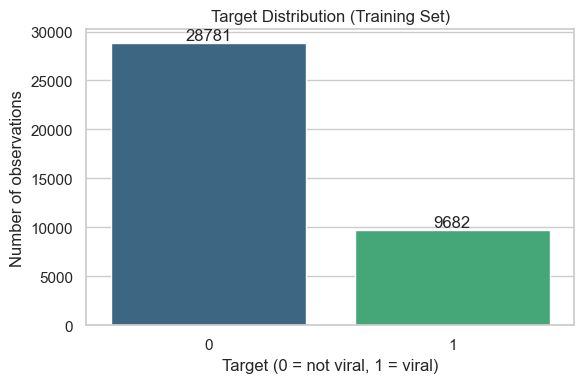

Positive class prevalence: 25.17%
Imbalance ratio (negatives : positives) = 2.97 : 1

Dataset treated as imbalanced: True


In [18]:
# --- Target distribution ---
counts = y_train.value_counts().sort_index()
positive_prevalence = y_train.mean()

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values, ax=ax,
            hue=counts.index, palette="viridis", legend=False)
ax.set_title("Target Distribution (Training Set)")
ax.set_xlabel("Target (0 = not viral, 1 = viral)")
ax.set_ylabel("Number of observations")

for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

print(f"Positive class prevalence: {positive_prevalence:.2%}")
imbalance_ratio = (1 - positive_prevalence) / positive_prevalence
print(f"Imbalance ratio (negatives : positives) = {imbalance_ratio:.2f} : 1")

is_imbalanced = not (0.40 <= positive_prevalence <= 0.60)
print(f"\nDataset treated as imbalanced: {is_imbalanced}")

The target is derived from a 4-level variable that is approximately evenly distributed:
the positive class therefore accounts for about a quarter of the total. The imbalance is moderate, not extreme, but sufficient to make accuracy an unreliable metric.

In [19]:
# --- Systematic Audit of Univariate Predictive Power ---

# AUROC
numerical_columns = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = [c for c in X_train.columns if c not in numerical_columns]

rows = []
for col in numerical_columns:
    auc = roc_auc_score(y_train, X_train[col])
    stat, p_val = mannwhitneyu(X_train.loc[y_train == 1, col],
                               X_train.loc[y_train == 0, col],
                               alternative="two-sided")
    rows.append({"variable": col, "type": "numerical",
                  "univariate_auroc": max(auc, 1 - auc), "p_value": p_val,
                  "n_levels": X_train[col].nunique()})

for col in categorical_columns:
    table = pd.crosstab(X_train[col], y_train)
    chi2, p_val, dof, expected = chi2_contingency(table)
    rows.append({"variable": col, "type": "categorical",
                  "univariate_auroc": np.nan, "p_value": p_val,
                  "n_levels": X_train[col].nunique()})

audit = pd.DataFrame(rows).sort_values("p_value")
audit["significant_5pct"] = audit["p_value"] < 0.05

print("Univariate predictive power audit:")
display(audit.round(4))

n_signif = int(audit["significant_5pct"].sum())
n_total = len(audit)
expected_by_chance = 0.05 * n_total

print(f"\nVariables significant at 5%: {n_signif} out of {n_total}")
print(f"Expected number by pure chance (false positives): {expected_by_chance:.1f}")

Univariate predictive power audit:


,variable,type,univariate_auroc,p_value,n_levels,significant_5pct
49,creator_tier,categorical,NaN,0.0804,2,False
39,source_hint,categorical,NaN,0.1170,3,False
33,category,categorical,NaN,0.1178,19,False
45,publish_period,categorical,NaN,0.1193,4,False
0,week_of_year,numerical,0.5052,0.1220,35,False
38,music_track,categorical,NaN,0.1302,61,False
55,traffic_source,categorical,NaN,0.1508,6,False
43,trend_type,categorical,NaN,0.1697,3,False
16,creator_avg_views,numerical,0.5041,0.2280,720,False
50,season,categorical,NaN,0.2415,4,False



Variables significant at 5%: 0 out of 56
Expected number by pure chance (false positives): 2.8


If the number of 'significant' variables is of the same order of magnitude as those expected by pure chance, there is no evidence of a systematic relationship between predictors and target. When testing dozens of variables at 5%, some will turn out significant by definition: this is the multiple testing problem, not a signal.

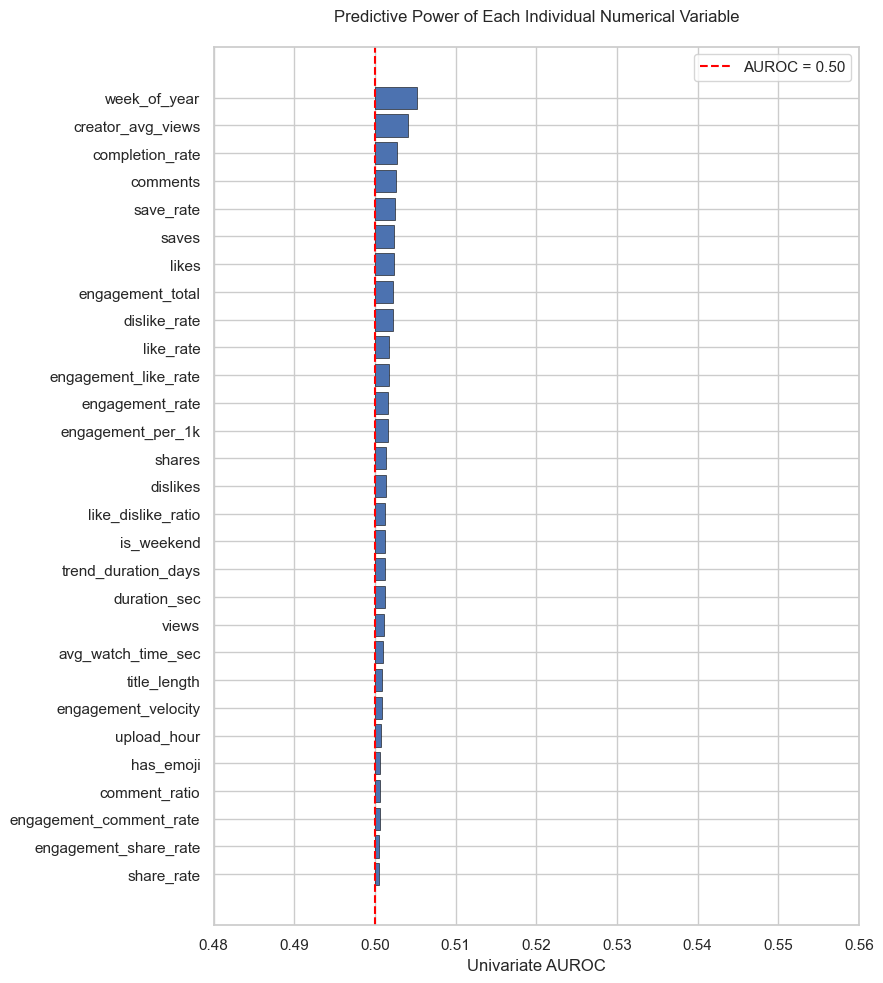

Maximum observed univariate AUROC: 0.5052
No numerical variable deviates appreciably from 0.50.

Pearson Correlation with the Target:


,correlation
dislikes,0.0124
saves,0.0092
likes,0.0088
engagement_total,0.0085
week_of_year,0.0079
engagement_velocity,0.0078
views,0.0072
comments,0.0065
creator_avg_views,-0.0058
shares,0.0056


Maximum absolute correlation: 0.0124


In [20]:
# --- Graphical Representation of the Audit ---
audit_num = audit[audit["type"] == "numerical"].sort_values("univariate_auroc", ascending=True)

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(audit_num["variable"], audit_num["univariate_auroc"] - 0.5,
        left=0.5, color="#4C72B0", edgecolor="black", linewidth=0.4)
ax.axvline(0.5, color="red", linestyle="--", linewidth=1.5,
           label="AUROC = 0.50")
ax.set_xlim(0.48, 0.56)
ax.set_xlabel("Univariate AUROC")
ax.set_title("Predictive Power of Each Individual Numerical Variable\n")
ax.legend()
plt.tight_layout(); plt.show()

print(f"Maximum observed univariate AUROC: {audit_num['univariate_auroc'].max():.4f}")
print("No numerical variable deviates appreciably from 0.50.")

# --- Correlation Matrix with the Target ---
corr_target = X_train[numerical_columns].corrwith(y_train).sort_values(key=abs, ascending=False)

print("\nPearson Correlation with the Target:")
display(corr_target.head(10).round(4).to_frame("correlation"))
print(f"Maximum absolute correlation: {corr_target.abs().max():.4f}")

### 3.4 High-Cardinality Encoding and Overfitting

The previous audit indicates an absence of signal. However, there is a path that would yield apparently excellent performance, and it is instructive to demonstrate it specifically to document why it was not taken.

The dataset contains columns with very high cardinality: tags (approximately 3.500 distinct values), title (approximately 2.100), and author_handle (720). Applying **target encoding** to these features (replacing each level with the mean target rate observed for that level) yields a substantial in-sample AUROC.

However, that value is entirely fictitious. With roughly 14 observations per level, the mean rate calculated on a given level is largely determined by the exact same rows on which performance is subsequently measured: the encoded variable literally contains a noisy copy of the target. This is leakage in its most insidious form because it requires no coding error — only a conceptual oversight.

The following cell measures both quantities — in-sample and out-of-sample exclusively within the Training Set using an internal split. The gap between the two columns is the direct measure of this illusion.

,variable,n_levels,rows_per_level,in_sample_AUROC,out_of_sample_AUROC,illusion_gap
0,tags,3104,9.3,0.6933,0.4975,0.1958
1,title,2099,13.7,0.6498,0.5081,0.1417
2,author_handle,720,40.1,0.6012,0.4914,0.1098
3,title_keywords,137,210.6,0.5422,0.5108,0.0314
4,music_track,61,472.9,0.5316,0.5066,0.0250
5,country,30,961.6,0.5210,0.5029,0.0181


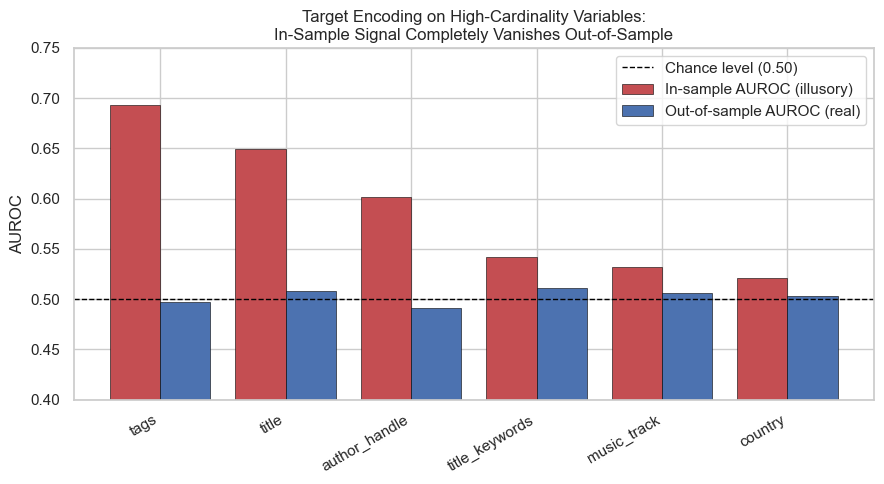

In [21]:
# --- Target Encoding Proof of Concept ---

X_tr_int, X_val_int, y_tr_int, y_val_int = train_test_split(
    X_train, y_train,
    test_size=0.25, 
    stratify=y_train, 
    random_state=RANDOM_STATE
)

high_card_features = ["tags", "title", "author_handle", "title_keywords",
                      "music_track", "country"]

compare_encoding = []
for col in high_card_features:
    rate_map = y_tr_int.groupby(X_tr_int[col]).mean()
    prior = y_tr_int.mean()

    auc_in = roc_auc_score(y_tr_int, X_tr_int[col].map(rate_map).fillna(prior))
    auc_out = roc_auc_score(y_val_int, X_val_int[col].map(rate_map).fillna(prior))

    compare_encoding.append({
        "variable": col,
        "n_levels": X_tr_int[col].nunique(),
        "rows_per_level": round(len(X_tr_int) / X_tr_int[col].nunique(), 1),
        "in_sample_AUROC": round(auc_in, 4),
        "out_of_sample_AUROC": round(auc_out, 4),
        "illusion_gap": round(auc_in - auc_out, 4),
    })

df_encoding = pd.DataFrame(compare_encoding).sort_values("illusion_gap", ascending=False)
display(df_encoding)

fig, ax = plt.subplots(figsize=(9, 5))
pos = np.arange(len(df_encoding))
ax.bar(pos - 0.2, df_encoding["in_sample_AUROC"], width=0.4,
       label="In-sample AUROC (illusory)", color="#C44E52", edgecolor="black", linewidth=0.4)
ax.bar(pos + 0.2, df_encoding["out_of_sample_AUROC"], width=0.4,
       label="Out-of-sample AUROC (real)", color="#4C72B0", edgecolor="black", linewidth=0.4)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="Chance level (0.50)")
ax.set_xticks(pos); ax.set_xticklabels(df_encoding["variable"], rotation=30, ha="right")
ax.set_ylabel("AUROC"); ax.set_ylim(0.4, 0.75)
ax.set_title("Target Encoding on High-Cardinality Variables:\nIn-Sample Signal Completely Vanishes Out-of-Sample")
ax.legend()
plt.tight_layout(); plt.show()


The entire apparent predictive power of these variables is memorization of training sample noise. Out-of-sample, the AUROC falls back to chance level. High-cardinality variables are therefore excluded from the feature set, and no target encoding is employed.

### 3.5 Anomaly detection

Social media engagement metrics follow long-tailed distributions: a handful of contents gather orders of magnitude more views than the median. These extreme values are not measurement errors: they are the very phenomenon under study.

Removing these rows would be counterproductive. It would mean discarding the exact high-reach contents we want to analyze. The chosen approach is **Winsorization**: the observation is retained, its relative ranking is preserved, but the leverage it exerts on the model's scale parameters is contained.

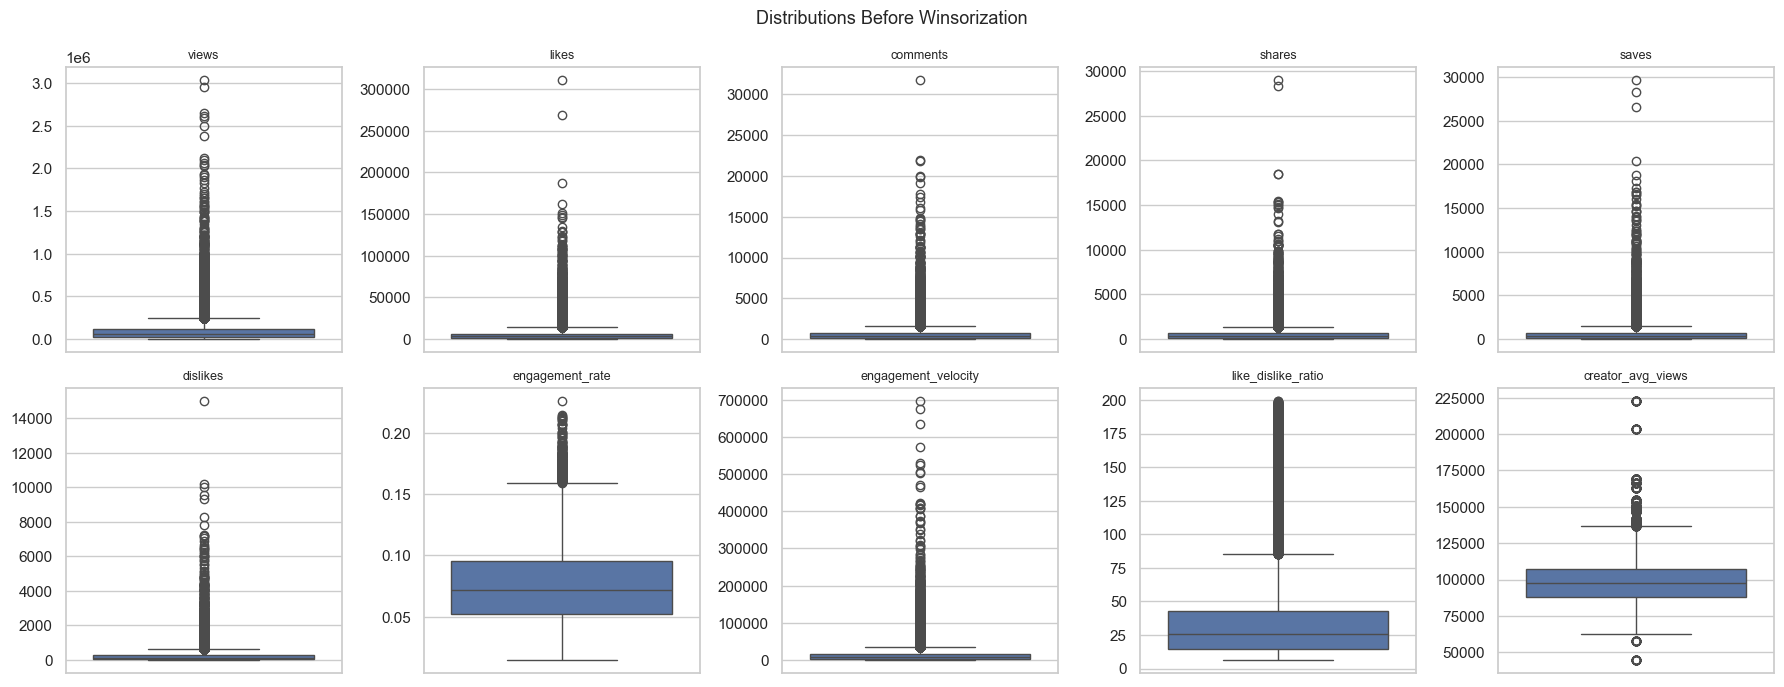

Skewness index before treatment:


,skewness
engagement_velocity,7.65
dislikes,7.62
shares,7.33
saves,7.27
likes,7.07
comments,6.75
views,5.61
like_dislike_ratio,2.14
creator_avg_views,1.03
engagement_rate,0.62


In [22]:
class WinsorizerPercentile:
    def __init__(self, lower_percentile=0.01, upper_percentile=0.99):
        self.lower_percentile = lower_percentile
        self.upper_percentile = upper_percentile
        self.limits_ = {}

    def fit(self, X, columns=None):
        columns = columns if columns is not None else X.select_dtypes(include=[np.number]).columns
        for col in columns:
            self.limits_[col] = (X[col].quantile(self.lower_percentile),X[col].quantile(self.upper_percentile))
        return self

    def transform(self, X):
        X_out = X.copy()
        for col, (inf, sup) in self.limits_.items():
            if col in X_out.columns:
                X_out[col] = X_out[col].clip(lower=inf, upper=sup)
        return X_out


# --- Distributions before treatment ---
columns_to_winsorize = ["views", "likes", "comments", "shares", "saves",
                        "dislikes", "engagement_rate", "engagement_velocity",
                        "like_dislike_ratio", "creator_avg_views"]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.ravel(), columns_to_winsorize):
    sns.boxplot(y=X_train[col], ax=ax, color="#4C72B0")
    ax.set_title(col, fontsize=9); ax.set_ylabel("")
fig.suptitle("Distributions Before Winsorization", fontsize=13)
plt.tight_layout(); plt.show()

# --- Quantifying skewness ---
skewness = X_train[columns_to_winsorize].skew().sort_values(ascending=False)
print("Skewness index before treatment:")
display(skewness.round(2).to_frame("skewness"))


Strongly positive values confirm long right-skewed tails, consistent with the nature of the phenomenon: a few contents concentrate most of the exposure.

In [23]:
# --- Learning limits on Train ---
winsorizer = WinsorizerPercentile(0.01, 0.99)
winsorizer.fit(X_train, columns=columns_to_winsorize)

X_train = winsorizer.transform(X_train)
X_test = winsorizer.transform(X_test)

print("Clipping limits learned on the Training Set:")
display(pd.DataFrame(winsorizer.limits_, index=["lower_limit", "upper_limit"]).T.round(3))

skewness_post = X_train[columns_to_winsorize].skew()
skewness_comparison = pd.DataFrame({"skew_before": skewness,
                                     "skew_after": skewness_post}).round(2)
print("\nEffect of Winsorization on skewness:")
display(skewness_comparison)


Clipping limits learned on the Training Set:


,lower_limit,upper_limit
views,5931.960,627974.560
likes,262.000,39631.740
comments,26.000,4473.760
shares,23.000,3857.900
saves,21.000,4444.380
dislikes,6.000,1887.280
engagement_rate,0.026,0.156
engagement_velocity,301.849,110707.455
like_dislike_ratio,6.788,165.824
creator_avg_views,66324.200,148726.300



Effect of Winsorization on skewness:


,skew_before,skew_after
comments,6.75,2.84
creator_avg_views,1.03,0.60
dislikes,7.62,2.96
engagement_rate,0.62,0.53
engagement_velocity,7.65,2.97
like_dislike_ratio,2.14,2.03
likes,7.07,2.77
saves,7.27,2.94
shares,7.33,2.79
views,5.61,2.61


### 3.6 Temporal Consistency Audit

Variables derived from a date are recalculable and therefore verifiable: if the dataset states that a row published on January 4th belongs to spring, that assertion can be cross-checked against the calendar. 

All columns derivable from `publish_date_approx` are verified by comparing the declared value with the recalculated one. The check is conducted exclusively on the Training Set.

In [25]:
# --- Reconstructing Temporal Features from Publication Date ---
time_audit = X_train[["publish_date_approx", "season", "event_season", "week_of_year",
                      "year_month", "publish_dayofweek", "is_weekend", "upload_hour",
                      "publish_period", "country"]].copy()
time_audit["date"] = pd.to_datetime(time_audit["publish_date_approx"], dayfirst=True)
time_audit["month"] = time_audit["date"].dt.month

print("Time coverage of the Training Set:")
print(f"  from {time_audit['date'].min().date()} to {time_audit['date'].max().date()}")
print(f"  months present: {sorted(time_audit['month'].unique())}")

# --- Verifying Deterministically Recalculable Columns ---
consistency_checks = {
    "year_month == formatted date":
        (time_audit["year_month"] == time_audit["date"].dt.strftime("%Y-%m")).mean(),
    "week_of_year == ISO week of the date":
        (time_audit["week_of_year"] == time_audit["date"].dt.isocalendar().week.astype(int)).mean(),
    "publish_dayofweek == day of the week of the date":
        (time_audit["publish_dayofweek"] == time_audit["date"].dt.day_name()).mean(),
}

# --- Verifying 'season' against the astronomical calendar ---
NORTHERN_SEASON_MAP = {12: "Winter", 1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring",
                       5: "Spring", 6: "Summer", 7: "Summer", 8: "Summer", 9: "Fall",
                       10: "Fall", 11: "Fall"}
time_audit["expected_season"] = time_audit["month"].map(NORTHERN_SEASON_MAP)
consistency_checks["season == season of the month (Northern Hemisphere)"] = (
    time_audit["season"] == time_audit["expected_season"]).mean()

time_audit_results = pd.DataFrame([(k, round(v, 4),
                                    "CONSISTENT" if v > 0.99 else "INCONSISTENT")
                                   for k, v in consistency_checks.items()],
                                  columns=["check", "consistent_ratio", "status"])
display(time_audit_results)


Time coverage of the Training Set:
  from 2025-01-01 to 2025-08-31
  months present: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8)]


,check,consistent_ratio,status
0,year_month == formatted date,1.0000,CONSISTENT
1,week_of_year == ISO week of the date,1.0000,CONSISTENT
2,publish_dayofweek == day of the week of the date,1.0000,CONSISTENT
3,season == season of the month (Northern Hemisp...,0.2507,INCONSISTENT


Distribution of 'season' by publication month:


season,Fall,Spring,Summer,Winter
month,,,,
1,1183,1182,1300,1108
2,1057,1073,1180,1061
3,1219,1178,1285,1184
4,1179,1077,1298,1124
5,1192,1262,1420,1275
6,1135,1150,1270,1103
7,1111,1207,1243,1163
8,1323,1237,1445,1239


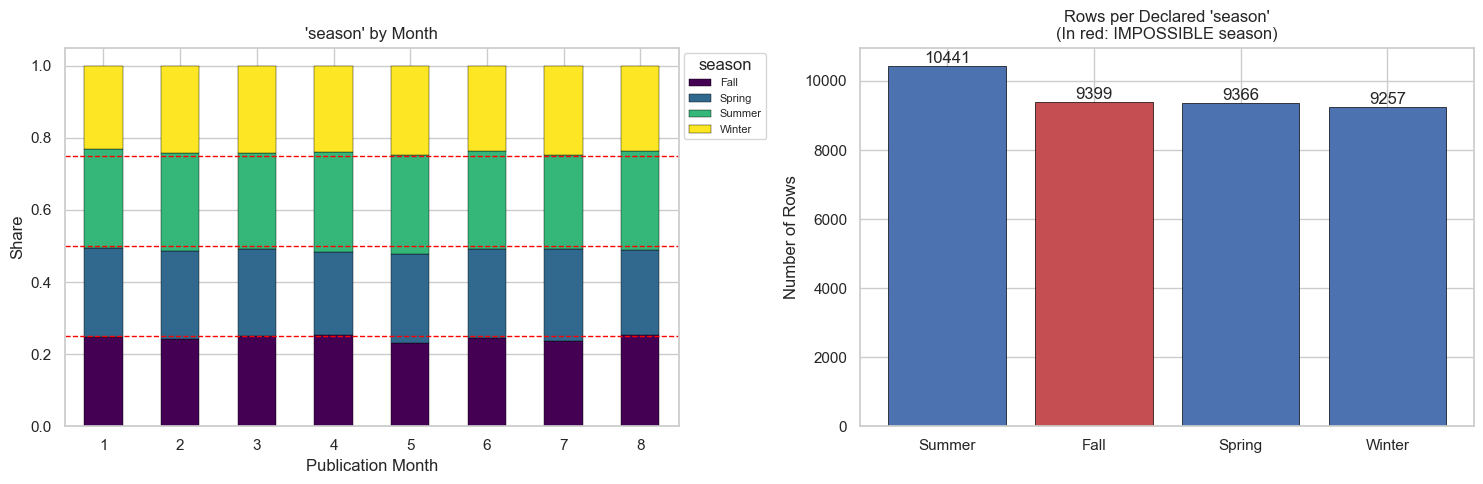

In [27]:
# --- Direct Proof: Declared Season is Independent of the Month ---
season_table = pd.crosstab(time_audit["month"], time_audit["season"])
print("Distribution of 'season' by publication month:")
display(season_table)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
shares = season_table.div(season_table.sum(axis=1), axis=0)
shares.plot(kind="bar", stacked=True, ax=ax, colormap="viridis", edgecolor="black", linewidth=0.3)
ax.axhline(0.25, color="red", linestyle="--", linewidth=1)
ax.axhline(0.50, color="red", linestyle="--", linewidth=1)
ax.axhline(0.75, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Publication Month"); ax.set_ylabel("Share")
ax.set_title("'season' by Month")
ax.legend(title="season", bbox_to_anchor=(1.0, 1.0), fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=0)

ax = axes[1]
season_counts = time_audit["season"].value_counts()
colors = ["#C44E52" if s == "Fall" else "#4C72B0" for s in season_counts.index]
ax.bar(season_counts.index, season_counts.values, color=colors,
       edgecolor="black", linewidth=0.5)
ax.set_ylabel("Number of Rows")
ax.set_title("Rows per Declared 'season'\n(In red: IMPOSSIBLE season)")
for i, v in enumerate(season_counts.values):
    ax.text(i, v, f"{v}", ha="center", va="bottom")

plt.tight_layout(); plt.show()


The Training Set exclusively covers the months from January to August. The boreal autumn (September-November) is not covered by any date.

A season that cannot occur within the observed period appears in roughly a quarter of the rows. The column does not convey seasonal information: it contains a label assigned independently of the actual date.

In [28]:
# --- event_season: Same Diagnosis ---
print("Distribution of 'event_season' by month:")
display(pd.crosstab(time_audit["month"], time_audit["event_season"]))

# Ramadan 2025 took place from March 1st to March 30th
ramadan = time_audit[time_audit["event_season"] == "Ramadan"]
print("\n" + "=" * 78)
print("THE RAMADAN CASE: Geographic Constraint Respected, Temporal Constraint Absent")
print("=" * 78)
print(f"Countries where it appears: {sorted(ramadan['country'].unique())}")
print("  -> all Muslim-majority: the geographic logic is correct.")
print(f"\nMonths where it appears: {sorted(ramadan['month'].unique())}")


Distribution of 'event_season' by month:


event_season,BackToSchool,HolidaySeason,Ramadan,Regular,SummerBreak
month,,,,,
1,361,392,84,2636,1300
2,344,380,95,2372,1180
3,402,440,78,2661,1285
4,390,424,101,2465,1298
5,371,451,89,2818,1420
6,358,404,114,2512,1270
7,364,412,94,2611,1243
8,446,444,103,2806,1445



THE RAMADAN CASE: Geographic Constraint Respected, Temporal Constraint Absent
Countries where it appears: ['Ae', 'Eg', 'Ma', 'Sa']
  -> all Muslim-majority: the geographic logic is correct.

Months where it appears: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8)]


Ramadan 2025 took place entirely in March: the temporal logic is absent. It is also observed that HolidaySeason appears in June and July, BackToSchool in January and February, and SummerBreak in January: all allocations that are incompatible with the meaning of their respective labels.

#### Conclusion

| Column | Result | Decision |
|---|---|---|
| **`season`** | Random with respect to the date (~0.25 consistency across 4 classes); includes an impossible season for the covered period | **Excluded** |
| **`event_season`** | Geographic constraint correct, temporal constraint absent | **Excluded** |

This audit transforms that qualitative evaluation into a documented fact: these are not weak variables, but rather variables devoid of any verifiable information content.

## 4 Feature Engineering

### 4.1 New Features

Raw metrics are confounded by audience size: 10,000 likes on 10 million views indicate lower engagement than 1,000 likes on 5,000 views. The engineered features aim to isolate three distinct dimensions:
- **Exposure Level** — `log_views`, `log_creator_avg_views`. Logarithmic compression linearizes distributions that span several orders of magnitude.
- **Penetration Beyond Organic Audience** — `views_vs_creator_baseline`, which is the ratio between the content's views and the creator's historical average. This is the semantically closest proxy to the concept of virality: it measures how far the algorithmic push propelled the content beyond the pre-existing audience.
- **Engagement Composition** — `quota_share`, `quota_comment`. For a given intensity, a sharing audience fuels distribution, whereas a commenting audience signals debate. 

In [29]:
def engineer_features(X):
    X = X.copy()
    eps = 1.0 

    # --- Exposure level, compressed scale ---
    X["log_views"] = np.log1p(X["views"])
    X["log_creator_avg_views"] = np.log1p(X["creator_avg_views"])

    # --- Penetration beyond the creator's organic audience ---
    X["views_vs_creator_baseline"] = X["views"] / (X["creator_avg_views"] + eps)

    # --- Engagement composition ---
    X["quota_share"] = X["shares"] / (X["engagement_total"] + eps)
    X["quota_comment"] = X["comments"] / (X["engagement_total"] + eps)

    return X


X_train = engineer_features(X_train)
X_test = engineer_features(X_test)

print("New engineered features built:")
for f in ["log_views", "log_creator_avg_views", "views_vs_creator_baseline",
          "quota_share", "quota_comment"]:
    print(f"  {f:<30} mean={X_train[f].mean():>10.4f}   std={X_train[f].std():>10.4f}")


New engineered features built:
  log_views                      mean=   11.0024   std=    0.9785
  log_creator_avg_views          mean=   11.4913   std=    0.1551
  views_vs_creator_baseline      mean=    0.9726   std=    1.0588
  quota_share                    mean=    0.0737   std=    0.0155
  quota_comment                  mean=    0.0838   std=    0.0208



### 4.2 Feature Selection

The redundancy audit in Section 3.2 proved that engagement_rate, like_rate, comment_ratio, share_rate, and save_rate are bound by an exact identity. Consequently, only engagement_rate is retained as an aggregate measure of intensity, paired with the two composition shares: this preserves information while avoiding perfect collinearity.

The following are excluded with explicit rationales:

| Features | Reason |
|---|---|
| `trend_label` | Deterministic source of the target (leakage) |
| `row_id` | Unique identifier, no generalizable information |
| `tags`, `title`, `author_handle`, `title_keywords`, `music_track` | High cardinality: demonstrated in 3.4 as a source of pure overfitting |
| `engagement_per_1k`, `like_rate`, `save_rate`, `engagement_total` | Exact algebraic redundancy |
| `sample_comments`, `notes`, `source_hint` | Collection metadata, devoid of causal rationale |
| `genre` | Heavily overlapping with `category` |

In [30]:
# --- Final Feature Set ---
numeric_features = [
    "log_views",                  # overall exposure of the content
    "log_creator_avg_views",      # typical audience size of the creator
    "views_vs_creator_baseline",  # penetration beyond organic reach
    "engagement_rate",            # aggregate intensity of interaction
    "quota_share",                # share of engagement dedicated to resharing
    "quota_comment",              # share of engagement dedicated to conversation
    "completion_rate",            # fraction of content actually watched
    "duration_sec",               # content length format
    "title_length",               # length of the title
]

categorical_features = [
    "platform",         # TikTok vs YouTube: distinct distribution algorithms
    "category",         # thematic vertical
    "traffic_source",   # discovery channel: ForYou implies algorithmic push
]

features = numeric_features + categorical_features

X_train = X_train[features]
X_test = X_test[features]

print(f"Selected features: {len(features)}")
print(f"  Numerical   ({len(numeric_features)}): {numeric_features}")
print(f"  Categorical ({len(categorical_features)}): {categorical_features}")
print(f"\nTrain shape: {X_train.shape}  |  Test shape: {X_test.shape}")

# --- Verification of Absence of Residual Collinearity ---
final_corr = X_train[numeric_features].corr().abs()
mask = np.triu(np.ones_like(final_corr, dtype=bool), k=1)
correlated_pairs = (final_corr.where(mask).stack().sort_values(ascending=False))

print("\nMost correlated pairs of numerical features:")
display(correlated_pairs.head(5).round(3).to_frame("absolute_correlation"))
print(f"Maximum residual correlation: {correlated_pairs.max():.3f}")


Selected features: 12
  Numerical   (9): ['log_views', 'log_creator_avg_views', 'views_vs_creator_baseline', 'engagement_rate', 'quota_share', 'quota_comment', 'completion_rate', 'duration_sec', 'title_length']
  Categorical (3): ['platform', 'category', 'traffic_source']

Train shape: (38463, 12)  |  Test shape: (9616, 12)

Most correlated pairs of numerical features:


absolute_correlation
log_views       views_vs_creator_baseline                 0.838
engagement_rate completion_rate                           0.300
                duration_sec                              0.219
quota_share     quota_comment                             0.138
completion_rate duration_sec                              0.137

Maximum residual correlation: 0.838


In [31]:
# --- Numerical Branch ---
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# --- Categorical Branch ---
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# --- Composition ---
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
)

print("ColumnTransformer configured.")


ColumnTransformer configured.
